# Week 1 Lab: Data Audit and Classical Baseline

**ECBS5200 — Practical Deep Learning Engineering**

This lab walks you through the complete **audit -> baseline -> interpret**
pipeline for a 113-class text classification problem. Some cells run as-is;
others require you to fill in answers, fix bugs, or write observations.
If you see `___`, you *must* replace it — Python will raise an error
otherwise.

**Time budget:** ~80 minutes (Parts 1-3).

## Kaggle setup (do this first!)

Before running any cells, go to **Settings** (gear icon, right sidebar):
1. Set **Persistence** to **"Variables and Files"** — saves your work if your session disconnects
2. Set **Internet** to **On** — needed to download the course repo and dataset

At the end of this lab, **download `week1_results.csv`** from the file
browser (right sidebar) — you'll need it in the homework notebook.

## Setup

In [1]:
import sys
import subprocess
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet",
    "transformers>=4.53", "datasets", "scikit-learn", "matplotlib", "pandas",
])

0

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

from pathlib import Path

# Load course utilities — works both locally (in the repo) and on Kaggle
REPO_PATH = Path("../..").resolve()
if not (REPO_PATH / "utils" / "data_utils.py").exists():
    import subprocess
    REPO_PATH = Path("/tmp/course")
    if not REPO_PATH.exists():
        subprocess.check_call(["git", "clone", "--depth", "1",
            "https://github.com/earino/applied-deep-learning.git", str(REPO_PATH)])
sys.path.insert(0, str(REPO_PATH))

from utils.data_utils import (
    load_course_data, LABEL_LIST, NUM_LABELS, LABEL_TO_ID, ID_TO_LABEL, MAX_LENGTH,
)

---
# Part 1: Data Audit (~35 min)
---

## Load the dataset

We use `utils/data_utils.py` to load the canonical dataset with consistent
splits and label mappings. This ensures every notebook in the course uses
exactly the same data.

In [3]:
train_ds, val_ds, test_ds = load_course_data()

print(f"Train:  {len(train_ds):,} examples")
print(f"Val:    {len(val_ds):,} examples")
print(f"Test:   {len(test_ds):,} examples")
print(f"Total:  {len(train_ds) + len(val_ds) + len(test_ds):,} examples")
print(f"\nNumber of classes: {NUM_LABELS}")
print(f"Columns: {train_ds.column_names}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Train:  57,846 examples
Val:    6,430 examples
Test:   21,432 examples
Total:  85,708 examples

Number of classes: 113
Columns: ['text', 'label', 'label_name']


## Label distribution

The dataset has 113 classes, but the distribution is extremely skewed.
A handful of classes dominate while most have very few examples.
This "long tail" is the central challenge of this classification task.

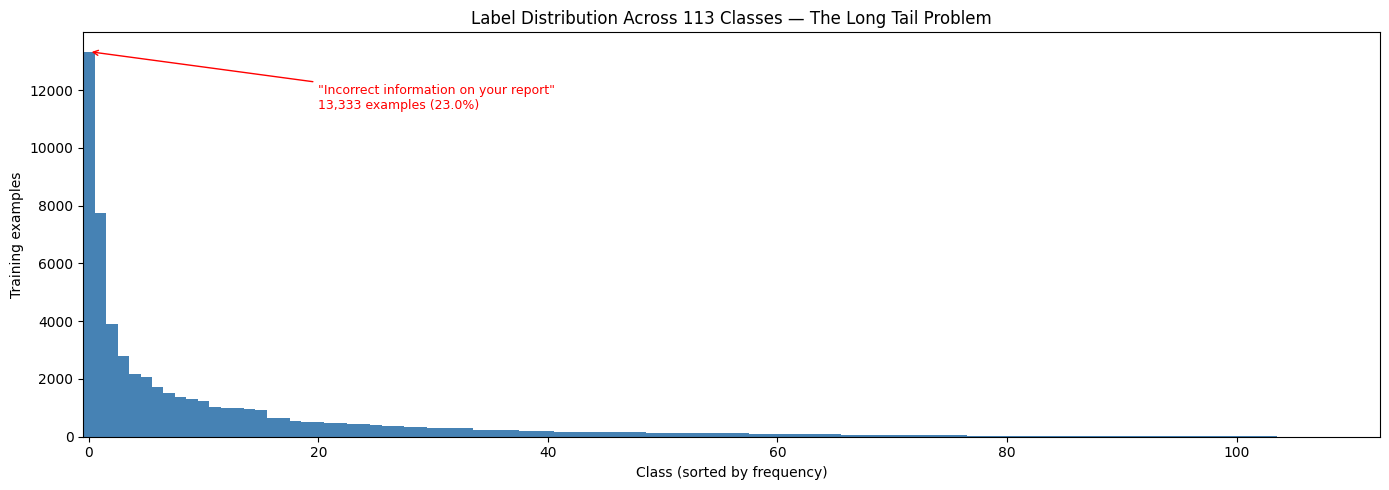

In [4]:
label_counts = Counter(train_ds["label_name"])
sorted_labels = label_counts.most_common()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(sorted_labels)), [c for _, c in sorted_labels], color="steelblue", width=1.0)
ax.set_xlabel("Class (sorted by frequency)")
ax.set_ylabel("Training examples")
ax.set_title(f"Label Distribution Across {NUM_LABELS} Classes — The Long Tail Problem")
ax.set_xlim(-0.5, len(sorted_labels) - 0.5)

# Annotate the majority class
top_label, top_count = sorted_labels[0]
ax.annotate(
    f'"{top_label}"\n{top_count:,} examples ({100*top_count/len(train_ds):.1f}%)',
    xy=(0, top_count), xytext=(20, top_count * 0.85),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9, color="red",
)

plt.tight_layout()
plt.show()

## Predict-then-observe: How concentrated is the long tail?

Look at the chart above carefully. The top 3 classes clearly dominate.

**Before running the next cell, write your prediction:**
What percentage of *all* training examples do you think the top 3 classes
account for?

In [5]:
# INTERACTIVE: Replace ___ with your estimate (a number, e.g. 40)
your_top3_pct_estimate = 80

In [6]:
# Now let's compute the actual answer
top3_count = sum(count for _, count in sorted_labels[:3])
top3_pct = 100 * top3_count / len(train_ds)

print(f"Your estimate:  {your_top3_pct_estimate}%")
print(f"Actual answer:  {top3_pct:.1f}%")
print(f"\nThe top 3 classes are:")
for label, count in sorted_labels[:3]:
    print(f'  "{label}" — {count:,} examples ({100*count/len(train_ds):.1f}%)')

if abs(your_top3_pct_estimate - top3_pct) < 5:
    print("\nNice — your intuition was close!")
else:
    print(f"\nOff by {abs(your_top3_pct_estimate - top3_pct):.1f} percentage points — the imbalance is striking.")

Your estimate:  80%
Actual answer:  43.2%

The top 3 classes are:
  "Incorrect information on your report" — 13,333 examples (23.0%)
  "Attempts to collect debt not owed" — 7,751 examples (13.4%)
  "Improper use of your report" — 3,905 examples (6.8%)

Off by 36.8 percentage points — the imbalance is striking.


## Top 10 and bottom 10 classes

The top class has thousands of examples. The bottom classes have barely
enough to learn from. Any model that ignores the rare classes can still
look decent on accuracy — which is why we care about **macro F1**.

In [7]:
print("TOP 10 classes by count:")
print("-" * 70)
for label, count in sorted_labels[:10]:
    pct = 100 * count / len(train_ds)
    print(f"  {count:>5,}  ({pct:5.1f}%)  {label}")

print(f"\n{'...'}\n")

print("BOTTOM 10 classes by count:")
print("-" * 70)
for label, count in sorted_labels[-10:]:
    pct = 100 * count / len(train_ds)
    print(f"  {count:>5,}  ({pct:5.1f}%)  {label}")

TOP 10 classes by count:
----------------------------------------------------------------------
  13,333  ( 23.0%)  Incorrect information on your report
  7,751  ( 13.4%)  Attempts to collect debt not owed
  3,905  (  6.8%)  Improper use of your report
  2,793  (  4.8%)  Communication tactics
  2,157  (  3.7%)  Disclosure verification of debt
  2,053  (  3.5%)  Problem with a credit reporting company's investigation into an existing problem
  1,723  (  3.0%)  Loan servicing, payments, escrow account
  1,526  (  2.6%)  Dealing with your lender or servicer
  1,374  (  2.4%)  Managing an account
  1,292  (  2.2%)  False statements or representation

...

BOTTOM 10 classes by count:
----------------------------------------------------------------------
      8  (  0.0%)  Problem with additional add-on products or services
      7  (  0.0%)  Overlimit fee
      6  (  0.0%)  Overdraft, savings, or rewards features
      6  (  0.0%)  Applying for a mortgage
      6  (  0.0%)  Advertising, mar

## Inspect a rare class

Pick one class from the bottom 10 above. Copy its name *exactly* into the
cell below (as a string). Then we'll sample a few examples from it.

In [8]:
# INTERACTIVE: Replace ___ with the name of a rare class from the bottom 10
# (copy-paste the exact string from the output above)
rare_class_to_inspect = "Applying for a mortgage"

In [9]:
# Sample examples from your chosen rare class
rare_indices = [i for i, name in enumerate(train_ds["label_name"]) if name == rare_class_to_inspect]

print(f'CLASS: "{rare_class_to_inspect}" ({len(rare_indices)} examples in train)')
print("=" * 70)
np.random.seed(42)
sample_indices = np.random.choice(rare_indices, size=min(3, len(rare_indices)), replace=False)
for idx in sample_indices:
    text = train_ds[int(idx)]["text"]
    print(f"\n  [{idx}] {text[:400]}{'...' if len(text) > 400 else ''}")
    print()

CLASS: "Applying for a mortgage" (6 examples in train)

  [2970] XXXX 2017, XXXX I have contacted this company more than one time to get this matter resolved. I have not received a phone or any feedback. It is reporting as derogatory for XXXX XXXX. I have never live there and the application was never complete. When I was going to sign a lease they change the cost of the rent before the move date application was never complete.


  [25078] A lengthy detailed explanation has been written and is Exhibit 21. Please read this first. It will provide details and reference the other 20 Exhibits that will be attached providing I can attach all of them. Just so you know I have contacted Security National Mortgage Company ( SNMC ) and have gotten no response at all from them.


  [32600] On  XXXX   XXXX ,  2017 ( or about ),  I was told that my loan request was sent to  Navy Federal Loan Committee with a request t o waive  XXXX  exceptions. I was told the request was denied.  <P/> However,  Navy

**What do these examples have in common? Why might this class be hard to classify?**

All of them are lengthly and do not start directly with the complaint.



## Text length distribution

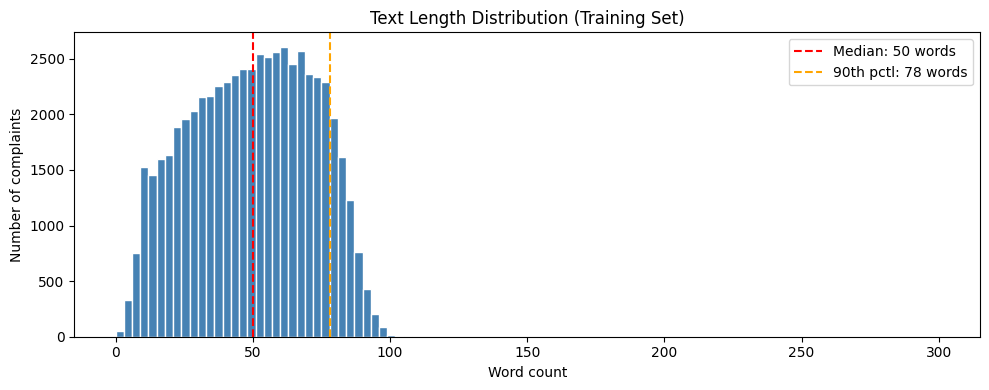

Median word count:      50
Mean word count:        49
90th percentile:        78
% with <= 50 words:     50.6%


In [10]:
word_counts = [len(text.split()) for text in train_ds["text"]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(word_counts, bins=100, color="steelblue", edgecolor="white", range=(0, 300))
ax.axvline(np.median(word_counts), color="red", linestyle="--", label=f"Median: {np.median(word_counts):.0f} words")
ax.axvline(np.percentile(word_counts, 90), color="orange", linestyle="--",
           label=f"90th pctl: {np.percentile(word_counts, 90):.0f} words")
ax.set_xlabel("Word count")
ax.set_ylabel("Number of complaints")
ax.set_title("Text Length Distribution (Training Set)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median word count:      {np.median(word_counts):.0f}")
print(f"Mean word count:        {np.mean(word_counts):.0f}")
print(f"90th percentile:        {np.percentile(word_counts, 90):.0f}")
print(f"% with <= 50 words:     {100 * np.mean(np.array(word_counts) <= 50):.1f}%")

The median complaint is around 50 words. With ModernBERT's tokenizer,
128 tokens covers roughly 85-90% of complaints without truncation.
We'll use `max_length=128` as our default — it's a good trade-off
between coverage and training speed.

## Redaction prevalence

The CFPB redacts personal information with "XXXX" placeholders. This is
a significant data characteristic — the model needs to handle these
gracefully rather than treating them as meaningful text.

In [11]:
redacted = [1 for text in train_ds["text"] if "XXXX" in text]
redacted_frac = len(redacted) / len(train_ds)

print(f"Complaints containing 'XXXX': {len(redacted):,} / {len(train_ds):,} ({100*redacted_frac:.1f}%)")

# Show an example
for i, text in enumerate(train_ds["text"]):
    if "XXXX" in text and len(text) < 500:
        print(f"\nExample redacted complaint:")
        print(f"  Label: {train_ds[i]['label_name']}")
        print(f"  Text:  {text}")
        break

Complaints containing 'XXXX': 36,722 / 57,846 (63.5%)

Example redacted complaint:
  Label: Incorrect information on your report
  Text:  I wrote Equifax on XXXX/XXXX/15 and alerted them to a XXXX account XXXX that is not mine. And they thus far have refused to answer my dispute NOR remove the item. I EVEN SUBMITTED A POLICE REPORT!


## Data audit synthesis

**Based on what you've seen so far, list two specific challenges this
dataset poses for a classifier.**

1. The class row count is skewed having a right tail, which needs special attention or loss function and not just accuracy.

2. 63.5 % of total rows have redacted text, which should be handled in preprocessign or training time.


---
# Part 2: Classical Baseline (~35 min)
---

## Fit TF-IDF + Logistic Regression

Before reaching for a neural model, we establish a floor with the
strongest classical text classifier: TF-IDF features + Logistic Regression.
This gives us a concrete number to beat and reveals exactly where
bag-of-words representations fall short.

**TF-IDF config:** 50K features, bigrams, sublinear TF scaling. This is
a strong classical setup — bigrams capture phrases like "late fee" that
unigrams miss, and sublinear TF prevents very frequent words from
dominating.

**LogReg config:** L2 penalty, `C=1.0`, `lbfgs` solver, up to 1000
iterations. LBFGS is the right solver for multinomial classification with
L2 — it's faster and more stable than SGD for this problem size.

In [12]:
print("Fitting TF-IDF vectorizer...")
t0 = time.time()

tfidf = TfidfVectorizer(
    max_features=50_000,
    sublinear_tf=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
)

X_train = tfidf.fit_transform(train_ds["text"])
X_val = tfidf.transform(val_ds["text"])

print(f"  TF-IDF matrix: {X_train.shape} (took {time.time()-t0:.1f}s)")
print(f"  Features: {X_train.shape[1]:,}")

Fitting TF-IDF vectorizer...
  TF-IDF matrix: (57846, 50000) (took 13.6s)
  Features: 50,000


In [13]:
print("Training Logistic Regression...")
t0 = time.time()

logreg = LogisticRegression(
    C=1.0,
    solver="lbfgs",
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
)
logreg.fit(X_train, train_ds["label"])

train_time = time.time() - t0
print(f"  Done in {train_time:.1f}s")

Training Logistic Regression...
  Done in 402.9s


## Evaluate on the validation set

In [14]:
val_preds = logreg.predict(X_val)

val_acc = accuracy_score(val_ds["label"], val_preds)
val_macro_f1 = f1_score(val_ds["label"], val_preds, average="macro", zero_division=0)
val_weighted_f1 = f1_score(val_ds["label"], val_preds, average="weighted", zero_division=0)

print(f"Validation Results:")
print(f"  Accuracy:     {val_acc:.4f}")
print(f"  Macro F1:     {val_macro_f1:.4f}")
print(f"  Weighted F1:  {val_weighted_f1:.4f}")

Validation Results:
  Accuracy:     0.5417
  Macro F1:     0.1334
  Weighted F1:  0.4789


## Predict-then-observe: How many classes get F1 = 0?

The accuracy is around 54%. That sounds mediocre but not terrible. But
remember, we have 113 classes and a very long tail.

**Before running the next cell, write your prediction:**
How many of the 113 classes do you think get F1 = 0 (the model never
correctly predicts them)?

In [15]:
# INTERACTIVE: Replace ___ with your guess (an integer, e.g. 30)
your_zero_f1_guess = 70

## Per-class F1 scores

Macro F1 averages F1 across all 113 classes equally. When many classes
get F1=0, that average gets dragged down hard. Let's see exactly how
many classes the model completely ignores.

In [16]:
report = classification_report(
    val_ds["label"], val_preds,
    labels=list(range(NUM_LABELS)),
    target_names=LABEL_LIST,
    zero_division=0,
    output_dict=True,
)

class_f1_scores = []
for i in range(NUM_LABELS):
    label_name = LABEL_LIST[i]
    f1 = report[label_name]["f1-score"]
    support = int(report[label_name]["support"])
    class_f1_scores.append((label_name, f1, support))

class_f1_scores.sort(key=lambda x: -x[1])

zero_f1_count = sum(1 for _, f1, _ in class_f1_scores if f1 == 0.0)

print(f"Your guess:     {your_zero_f1_guess} classes with F1 = 0")
print(f"Actual answer:  {zero_f1_count} / {NUM_LABELS} ({100*zero_f1_count/NUM_LABELS:.0f}%)")

if abs(your_zero_f1_guess - zero_f1_count) <= 10:
    print("\nGood intuition!")
else:
    print(f"\nOff by {abs(your_zero_f1_guess - zero_f1_count)} classes — the long tail is brutal.")

print(f"\nTop 10 classes by F1:")
print("-" * 70)
for name, f1, support in class_f1_scores[:10]:
    print(f"  F1={f1:.3f}  (n={support:>4})  {name[:55]}")

print(f"\nBottom 10 classes by F1 (all zero):")
print("-" * 70)
for name, f1, support in class_f1_scores[-10:]:
    print(f"  F1={f1:.3f}  (n={support:>4})  {name[:55]}")

Your guess:     70 classes with F1 = 0
Actual answer:  69 / 113 (61%)

Good intuition!

Top 10 classes by F1:
----------------------------------------------------------------------
  F1=0.750  (n=  23)  Money was not available when promised
  F1=0.728  (n= 434)  Improper use of your report
  F1=0.696  (n=1482)  Incorrect information on your report
  F1=0.652  (n=  45)  Problem caused by your funds being low
  F1=0.633  (n= 111)  Unable to get your credit report or credit score
  F1=0.621  (n= 169)  Dealing with your lender or servicer
  F1=0.614  (n= 191)  Loan servicing, payments, escrow account
  F1=0.607  (n= 861)  Attempts to collect debt not owed
  F1=0.596  (n= 310)  Communication tactics
  F1=0.580  (n= 113)  Loan modification,collection,foreclosure

Bottom 10 classes by F1 (all zero):
----------------------------------------------------------------------
  F1=0.000  (n=  17)  Threatened to contact someone or share information impr
  F1=0.000  (n=  52)  Took or threatened to tak

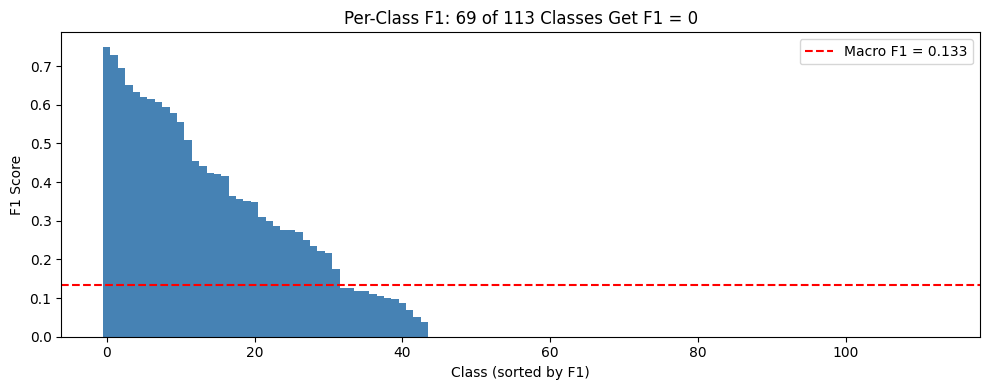

In [17]:
# Visualize the distribution of per-class F1 scores
f1_values = [f1 for _, f1, _ in class_f1_scores]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(f1_values)), f1_values, color="steelblue", width=1.0)
ax.axhline(val_macro_f1, color="red", linestyle="--", label=f"Macro F1 = {val_macro_f1:.3f}")
ax.set_xlabel("Class (sorted by F1)")
ax.set_ylabel("F1 Score")
ax.set_title(f"Per-Class F1: {zero_f1_count} of {NUM_LABELS} Classes Get F1 = 0")
ax.legend()
plt.tight_layout()
plt.show()

## Bug hunt: Confusion matrix for the top 10 classes

The cell below tries to build a confusion matrix for the 10 most
frequent classes. But there's a bug — it produces wrong results.

**Find and fix the bug before continuing.**

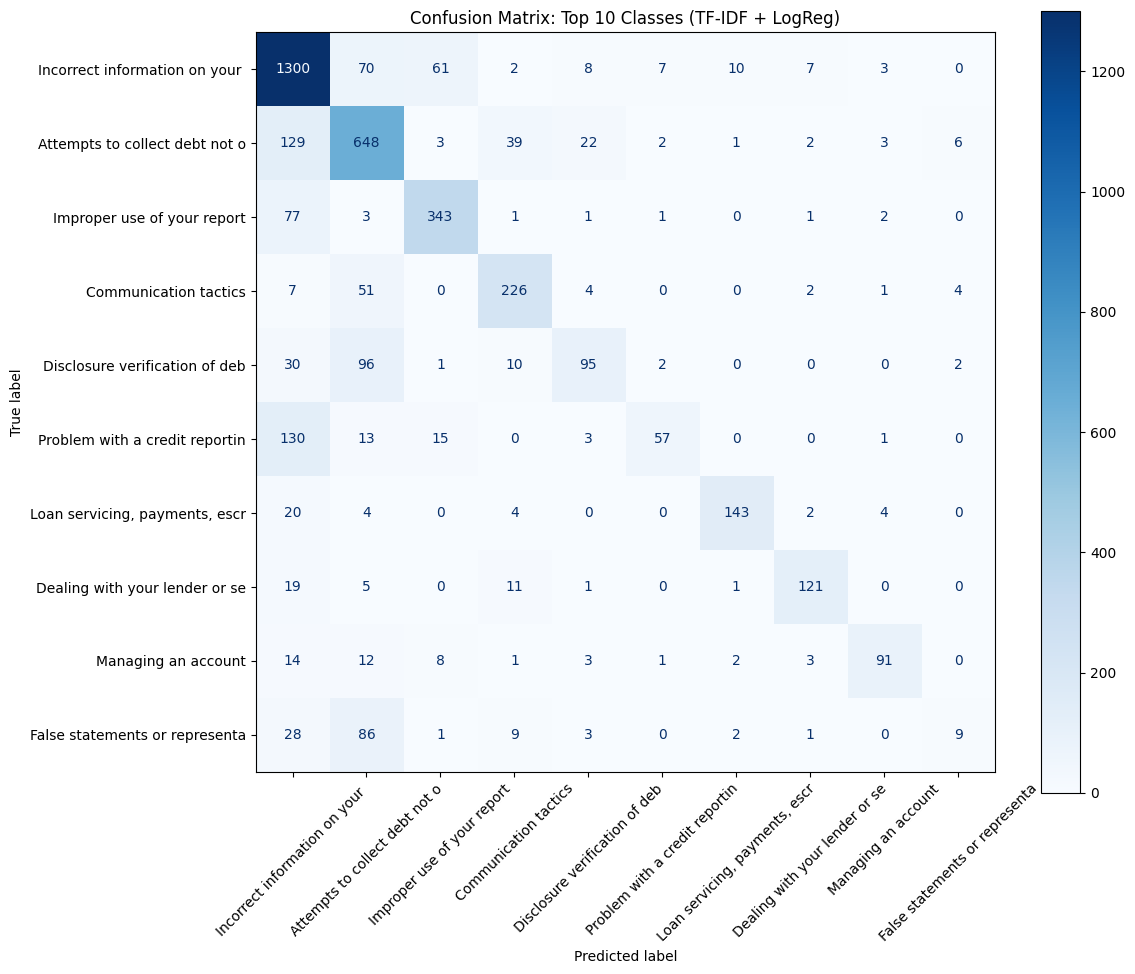

In [19]:
# BUG FIX: Build the confusion matrix from validation labels and predictions.
# The mask comes from val_ds, so both filtered arrays must come from val_ds too.

label_counts_by_id = Counter(train_ds["label"])
top_10_ids = [label for label, _ in label_counts_by_id.most_common(10)]
top_10_names = [ID_TO_LABEL[i] for i in top_10_ids]

mask = np.isin(val_ds["label"], top_10_ids)
filtered_true = np.array(val_ds["label"])[mask]
filtered_pred = val_preds[mask]

cm = confusion_matrix(filtered_true, filtered_pred, labels=top_10_ids)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=[n[:30] for n in top_10_names])
disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
ax.set_title("Confusion Matrix: Top 10 Classes (TF-IDF + LogReg)")
plt.tight_layout()
plt.show()

The bug was that the code built the mask from the validation set, but then applied to the train set. I fixed it by using `val_ds` consistently.

## Interpreting the confusion matrix

Now that the confusion matrix is fixed, look at the off-diagonal cells.

**Pick the two classes that the model confuses most often. Why do you
think these get confused?**

`Problem with a credit reporting` gets labeled `Incorrect information on your report` and the possible reason is that these complaints probably often contain the word "report".



---
# Part 3: Synthesis (~10 min)
---

## Log results

In [20]:
results = pd.DataFrame([{
    "model": "TF-IDF + LogReg",
    "accuracy": round(val_acc, 4),
    "macro_f1": round(val_macro_f1, 4),
    "weighted_f1": round(val_weighted_f1, 4),
    "zero_f1_classes": zero_f1_count,
    "train_time_sec": round(train_time, 1),
    "notes": "Classical baseline, 50k features, bigrams, C=1.0",
}])

print(results.to_string(index=False))
results.to_csv("week1_results.csv", index=False)
print("\nSaved to week1_results.csv")

          model  accuracy  macro_f1  weighted_f1  zero_f1_classes  train_time_sec                                            notes
TF-IDF + LogReg    0.5417    0.1334       0.4789               69           402.9 Classical baseline, 50k features, bigrams, C=1.0

Saved to week1_results.csv


## Final reflection

**Write one sentence: what is the single most important thing a neural
model needs to do better than this baseline?**

The one metric that is outstandingly low quality with logreg is `zero_f1_classes`, this should be improved.

## What's next

In the homework notebook, you'll fine-tune ModernBERT-base and find out
whether it can rescue those ~70 zero-F1 classes. The audit you just did
gives you a concrete set of expectations: you know which classes are hard,
why the baseline fails, and what "better" looks like in terms of macro F1.